# 📦 Olist E-commerce — Exploratory Data Analysis (Customer Retention)
### From the Gold Mart to a board-room decision

**Author:** HoongJun · **Module 5 (Analytics)** · **Data:** `sctp-team2-project2-elt.olist_gold_mart_prod`

---

## Executive summary — read this first

> **The company is *buying* growth it should be *earning*.** The binding constraint
> on profitable growth is the **repeat-purchase rate**, and the single biggest
> controllable lever on it is **delivery experience**.

Three executives each see one face of the same elephant:

| Who | What they see | What they conclude | Why that's the wrong fix |
| --- | --- | --- | --- |
| **CEO** | GMV grows, but marketing spend climbs to sustain it; margins soft | "We're working harder to grow" | The leak is *retention*, not pricing or competition |
| **CMO** | Re-engagement underperforms, churn ugly | "Our brand isn't sticky → spend more on loyalty" | The churn cause is operational, not a comms problem |
| **CTO** | Delivery complaints, low review scores | "Logistics cost to optimise" (noise) | Those late deliveries *are* the revenue leak |

**What the data shows (validated in this notebook):**

1. **Retention is the constraint** — only **~3.5%** of orders are repeat purchases
   (96,096 customers → 99,441 orders). Growth ≈ pure new-customer acquisition.
2. **Delivery's tail is toxic** — ~**8%** of delivered orders arrive *late*.
3. **The smoking gun** — on-time orders average **4.3★**; late orders average
   **2.6★**, and **54%** of late-delivery customers leave a 1–2★ review.

**The chain:** *late delivery → low review → customer never returns → low repeat
rate → rising acquisition spend & soft margins.* The cause lives in the **CTO's**
domain, surfaces as the **CMO's** retention problem, and shows up in the **CEO's**
P&L. **Fixing delivery reliability is cheaper than buying replacement growth.**

---

## 1. How to read this notebook (and a 60-second pandas/seaborn primer)

This notebook is also a **learning artifact**. Every analysis step has three parts:

1. **🎯 Purpose** — *why* we run it (the business question).
2. **🧮 The code** — *what* it does, with comments on each pandas/seaborn idiom.
3. **🔍 Reading the result** — *how* to interpret the numbers/chart and what it implies.

**Vocabulary you'll see a lot:**

| Term | Plain meaning |
| --- | --- |
| `DataFrame` (`df`) | A table in memory — rows × named columns. Think "Excel sheet in Python." |
| `df.groupby('x')['y'].mean()` | "For each value of column *x*, average column *y*." (a pivot/summary) |
| `df['col']` | One column (a `Series`). `df[['a','b']]` selects several columns. |
| `df[df['x'] > 5]` | **Filtering** — keep only rows where the condition is True. |
| `.value_counts()` | Frequency table — how many rows fall in each category. |
| `sns.barplot(...)` | Seaborn = matplotlib with nicer defaults. `sns.*plot` draws the chart. |

You do **not** need to memorise these — the comments re-explain them in context.

### 1.1 Setup — connect to BigQuery

We read **gold-mart** tables (the trusted, modelled layer) directly into pandas.

**Authentication:** we use a **service-account keyfile** stored in `../secrets/`. To
run elsewhere, point `GOOGLE_APPLICATION_CREDENTIALS` at your own key — or, if no key
is found, the notebook falls back to your local `gcloud` login (ADC) so it still runs.

In [1]:
!pip install -q seaborn db-dtypes


In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery

warnings.filterwarnings("ignore")            # keep the notebook output clean for readers

# --- Visual defaults so every chart looks consistent & presentation-ready ---
sns.set_theme(style="whitegrid", palette="deep")   # whitegrid = light gridlines, easy to read
plt.rcParams["figure.figsize"] = (10, 5)           # default chart size (width, height in inches)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["figure.dpi"] = 110                   # crispness on screen
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")  # 1,234.50 instead of 1234.4999

PROJECT = "sctp-team2-project2-elt"
GOLD    = f"{PROJECT}.olist_gold_mart_prod"   # the gold mart (our contract)
SNAP    = f"{PROJECT}.snapshots"              # reviews_dbt_scd_snapshot lives here (has order_id)

# --- Build a BigQuery client using a service-account keyfile. ---
# Override the location anytime via:  export GOOGLE_APPLICATION_CREDENTIALS=/path/to/key.json
# Default path is relative to this notebook (notebooks/eda/) -> ../secrets/<key>.json
KEYFILE = os.environ.get(
    "GOOGLE_APPLICATION_CREDENTIALS",
    os.path.join("..", "secrets", "sctp-team2-project2-elt-ROTATED-dbcb3cd092f4.json"),
)

def make_client():
    # Authenticate with the service-account keyfile (the project's chosen method)...
    if os.path.exists(KEYFILE):
        try:
            from google.oauth2 import service_account
            creds = service_account.Credentials.from_service_account_file(KEYFILE)
            client = bigquery.Client(credentials=creds, project=PROJECT)
            client.query("SELECT 1").result()          # smoke-test the credentials
            print(f"✅ Authenticated with service-account keyfile: {KEYFILE}")
            return client
        except Exception as e:
            print(f"⚠️  Keyfile present but unusable ({str(e)[:60]}...). Falling back to gcloud ADC.")
    # ...fall back to Application Default Credentials (your `gcloud auth` login) if no key.
    client = bigquery.Client(project=PROJECT)
    client.query("SELECT 1").result()
    print("✅ Authenticated with gcloud Application Default Credentials (ADC).")
    return client

client = make_client()

def q(sql: str) -> pd.DataFrame:
    # Run SQL on BigQuery and return the result as a pandas DataFrame.
    return client.query(sql).to_dataframe()

✅ Authenticated with gcloud Application Default Credentials (ADC).


## 2. Data overview — what are we working with?

**🎯 Purpose:** before *any* analysis, understand the **grain** (what one row means),
the **size**, the **time span**, and where data is **missing**. Skipping this is how
analysts produce confident-but-wrong charts.

**The gold mart (star schema):**

```
                 dim_customers ──┐
                 dim_products  ──┤
                 dim_sellers   ──┼──< fact_orders >── reviews_dbt_scd_snapshot
                                 │     (1 row per order ITEM)      (1 row per review)
```

`fact_orders` is at **order-item grain** — an order with 3 items = 3 rows. So to talk
about *orders* we must aggregate items up to the order. We do that next.

In [4]:
# Pull ONE row per ORDER by aggregating the item-grain fact up to order grain.
# SUM(price) = order GMV; COUNT(*) = items in the order. ANY_VALUE picks the order-level
# attributes (identical across an order's items, so "any value" is safe).
sql_orders = f'''
WITH order_items AS (
  SELECT
    id                                   AS order_id,
    ANY_VALUE(customer_id)               AS customer_id,
    ANY_VALUE(order_status)              AS order_status,
    ANY_VALUE(order_purchase_timestamp)  AS purchase_ts,
    ANY_VALUE(order_approved_at)         AS approved_ts,
    ANY_VALUE(order_delivered_customer_date) AS delivered_ts,
    ANY_VALUE(order_estimated_delivery_date) AS estimated_ts,
    ANY_VALUE(payment_value)             AS payment_value,
    SUM(price)                           AS order_gmv,      -- product revenue for the order
    SUM(freight_value)                   AS order_freight,  -- shipping charged
    COUNT(*)                             AS item_count
  FROM `{GOLD}.fact_orders`
  GROUP BY id
),
cur_reviews AS (   -- current review per order (snapshot rows still valid today)
  SELECT order_id, MAX(review_score) AS review_score
  FROM `{SNAP}.reviews_dbt_scd_snapshot`
  WHERE dbt_valid_to IS NULL AND order_id IS NOT NULL
  GROUP BY order_id
)
SELECT
  o.*,
  c.customer_unique_id,           -- the SAME person across multiple orders (key to retention!)
  c.customer_state,
  r.review_score
FROM order_items o
LEFT JOIN `{GOLD}.dim_customers` c ON o.customer_id = c.id
LEFT JOIN cur_reviews            r ON o.order_id    = r.order_id
'''
orders = q(sql_orders)

# Make timestamps real datetimes so we can do date maths (subtract, resample by month).
for col in ["purchase_ts", "approved_ts", "delivered_ts", "estimated_ts"]:
    orders[col] = pd.to_datetime(orders[col])

print(f"orders table: {orders.shape[0]:,} rows  ×  {orders.shape[1]} columns")
orders.head(3)

orders table: 99,441 rows  ×  14 columns


,order_id,customer_id,order_status,purchase_ts,approved_ts,delivered_ts,estimated_ts,payment_value,order_gmv,order_freight,item_count,customer_unique_id,customer_state,review_score
0,d573a47c29466bb2e4e46aef0ff04f23,d5efb94fdd7fe8e0ba70c7580088acae,delivered,2017-02-03 01:06:06+00:00,2017-02-03 01:15:11+00:00,2017-05-05 00:09:56+00:00,2017-03-28 00:00:00+00:00,984.26,949.00,35.26,1,aaf7ed8313a90b1735dd28ab46546b30,AL,1
1,3c314f50bc654f3c4e317b055681dff9,c17d38e818f10c91ebcd036bc835a648,delivered,2017-03-16 14:36:05+00:00,2017-03-16 14:36:05+00:00,2017-04-24 09:18:11+00:00,2017-04-19 00:00:00+00:00,296.89,203.00,93.88,3,3b81cc8417be691f3159596da7e08a3c,PI,1
2,5ca60cc1a00a1d2f3090cebdd57c696e,965f78e2702c7775431e6a79a21ce549,delivered,2017-04-25 08:34:36+00:00,2017-04-25 08:45:08+00:00,2017-05-12 13:13:42+00:00,2017-05-24 00:00:00+00:00,295.45,189.99,105.46,1,aa6172137b971ed93e69466a599a9bb1,SE,1


**🧮 What just happened:** `orders.shape` returns `(rows, columns)`. `.head(3)` shows
the first 3 rows so we can eyeball the structure. One row = one **order**.

In [5]:
# .info() = the column inventory: name, count of NON-null values, and data type (dtype).
# Where "Non-Null Count" < total rows, that column has MISSING values.
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   order_id            99441 non-null  object             
 1   customer_id         99441 non-null  object             
 2   order_status        99441 non-null  object             
 3   purchase_ts         99441 non-null  datetime64[us, UTC]
 4   approved_ts         99281 non-null  datetime64[us, UTC]
 5   delivered_ts        96476 non-null  datetime64[us, UTC]
 6   estimated_ts        99441 non-null  datetime64[us, UTC]
 7   payment_value       99440 non-null  float64            
 8   order_gmv           98666 non-null  float64            
 9   order_freight       98666 non-null  float64            
 10  item_count          99441 non-null  Int64              
 11  customer_unique_id  99441 non-null  object             
 12  customer_state      99441 non-nu

Fetching comprehensive financial and cohort data from BigQuery...


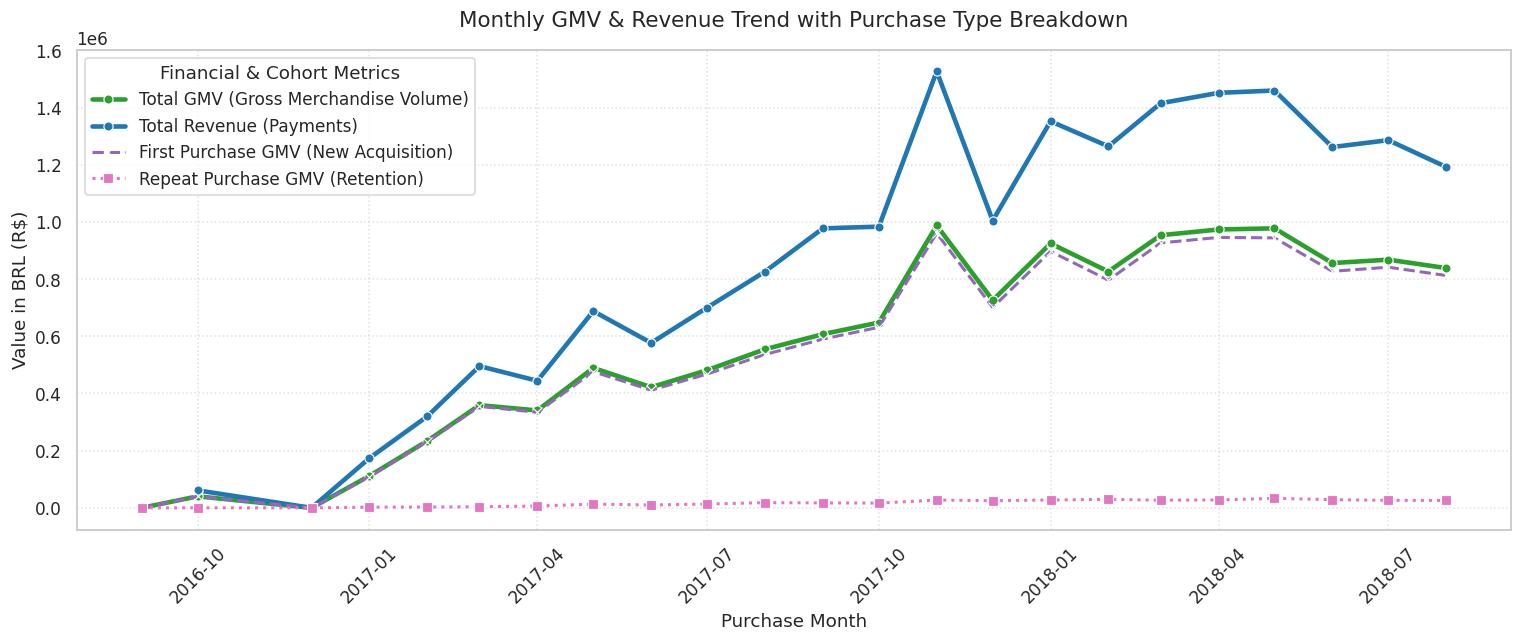

Fetching payment-level GMV data...


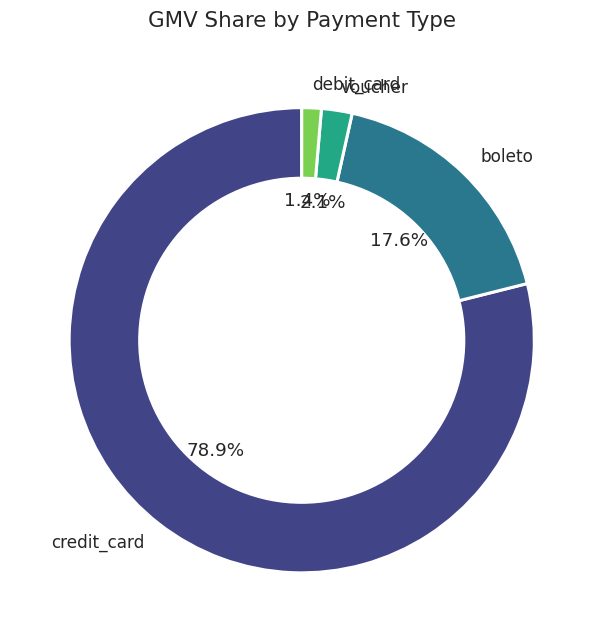

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =====================================================================
# 1. MONTHLY REVENUE, TOTAL GMV, & COHORT BREAKDOWN TREND
# =====================================================================

# Enhanced query to calculate order sequence per unique customer
revenue_query = """
WITH order_rank AS (
  SELECT
    id AS order_id,
    ANY_VALUE(customer_id) AS customer_id,
    ANY_VALUE(order_purchase_timestamp) AS purchase_ts
  FROM `olist_gold_mart_prod.fact_orders`
  WHERE order_status = 'delivered'
  GROUP BY id
),
customer_rank AS (
  SELECT
    order_id,
    purchase_ts,
    ROW_NUMBER() OVER (PARTITION BY c.customer_unique_id ORDER BY purchase_ts) AS order_seq
  FROM order_rank r
  LEFT JOIN `olist_gold_mart_prod.dim_customers` c ON r.customer_id = c.id
)
SELECT
  DATE_TRUNC(f.order_purchase_timestamp, MONTH) as order_month,
  SUM(f.price) as total_gmv,
  SUM(f.payment_value) as total_revenue,
  SUM(CASE WHEN cr.order_seq = 1 THEN f.price ELSE 0 END) as gmv_first_purchase,
  SUM(CASE WHEN cr.order_seq > 1 THEN f.price ELSE 0 END) as gmv_repeat_purchase
FROM `olist_gold_mart_prod.fact_orders` f
LEFT JOIN customer_rank cr ON f.id = cr.order_id
WHERE f.order_status = 'delivered'
GROUP BY order_month
ORDER BY order_month;
"""

print("Fetching comprehensive financial and cohort data from BigQuery...")
df_revenue = client.query(revenue_query).to_dataframe()

# Initialize the plot layout
plt.figure(figsize=(14, 6))

# Plot Core Metrics (Solid Lines)
sns.lineplot(
    data=df_revenue, 
    x="order_month", 
    y="total_gmv", 
    label="Total GMV (Gross Merchandise Volume)", 
    color="#2ca02c", 
    linewidth=3, 
    marker="o"
)
sns.lineplot(
    data=df_revenue, 
    x="order_month", 
    y="total_revenue", 
    label="Total Revenue (Payments)", 
    color="#1f77b4", 
    linewidth=3, 
    marker="o"
)

# Plot Cohort Breakdowns (Dotted Lines as requested)
sns.lineplot(
    data=df_revenue, 
    x="order_month", 
    y="gmv_first_purchase", 
    label="First Purchase GMV (New Acquisition)", 
    color="#9467bd",          # Executive Purple
    linewidth=2, 
    linestyle="--",           # Dashed to represent a sub-component
    marker="x"
)
sns.lineplot(
    data=df_revenue, 
    x="order_month", 
    y="gmv_repeat_purchase", 
    label="Repeat Purchase GMV (Retention)", 
    color="#e377c2",          # Distinct pink highlight
    linewidth=2, 
    linestyle=":",            # Clean dotted styling
    marker="s"
)

# Chart styling and labels
plt.title("Monthly GMV & Revenue Trend with Purchase Type Breakdown", fontsize=14, pad=15)
plt.xlabel("Purchase Month", fontsize=12)
plt.ylabel("Value in BRL (R$)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(title="Financial & Cohort Metrics", loc="upper left")
plt.tight_layout()
plt.show()


# =====================================================================
# 2. PAYMENT METHOD BREAKDOWN (BASED ON GMV)
# =====================================================================
payment_query = """
SELECT 
    payment_type,
    SUM(price) as total_gmv,
    COUNT(DISTINCT id) as order_count
FROM `olist_gold_mart_prod.fact_orders`
GROUP BY payment_type
ORDER BY total_gmv DESC;
"""

print("Fetching payment-level GMV data...")
df_payment = client.query(payment_query).to_dataframe()
df_payment = df_payment[df_payment["payment_type"] != "not_defined"]

plt.figure(figsize=(6, 6))
colors = sns.color_palette("viridis", len(df_payment))

plt.pie(
    df_payment["total_gmv"],
    labels=df_payment["payment_type"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 2, "antialiased": True},
)

centre_circle = plt.Circle((0, 0), 0.70, fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("GMV Share by Payment Type", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


🎉 Pie chart successfully generated and saved to your workspace as 'top_10_revenue_pie_chart.png'!


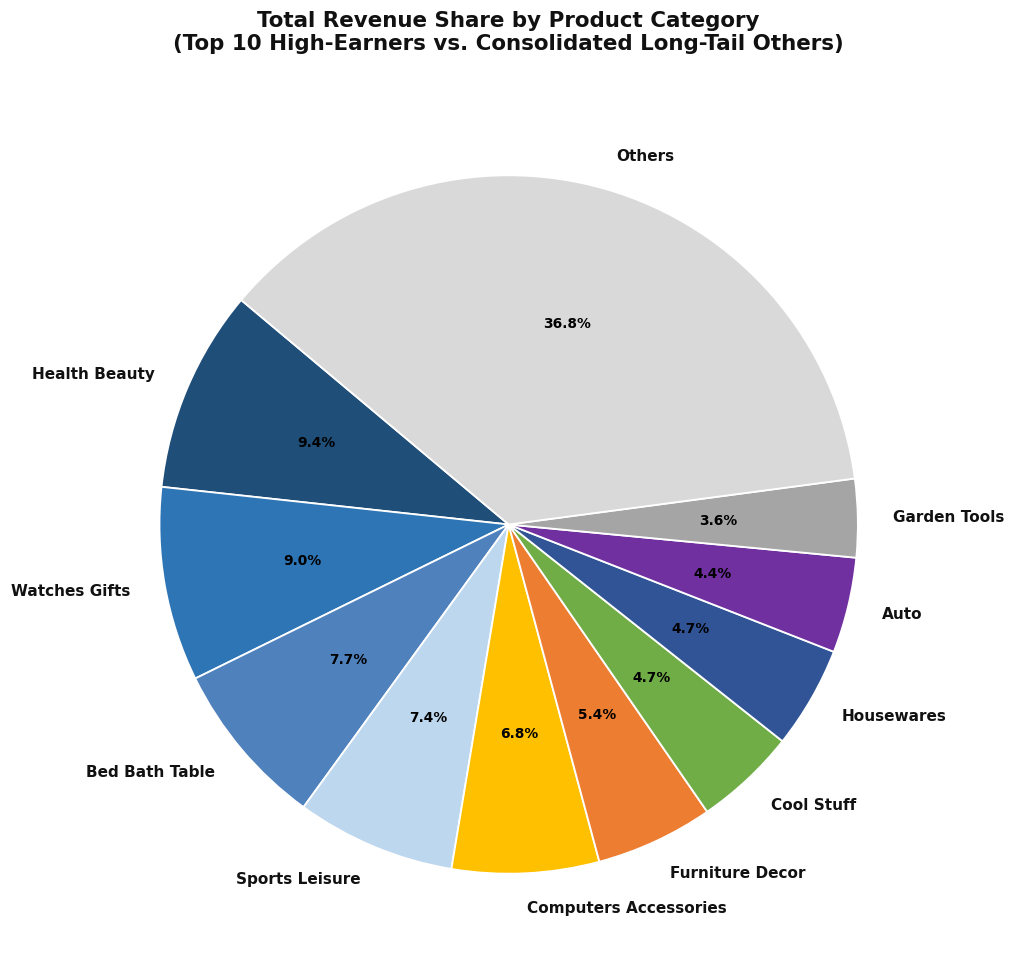

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the generated revenue data
csv_filename = "revenue_vs_product_category.csv"
try:
    df = pd.read_csv(csv_filename)
except FileNotFoundError:
    print(f"❌ '{csv_filename}' not found. Please run the revenue database query script first!")
    raise

# 2. Process data: Isolate Top 10 and consolidate the rest into "Others"
top_n = 10
df_top = df.head(top_n).copy()
df_others = df.iloc[top_n:]

# Calculate aggregate financial values for the remaining long-tail categories
others_revenue = df_others['total_revenue'].sum()

# Build the consolidated visual dataset
pie_data = pd.concat([
    df_top, 
    pd.DataFrame({'product_category': ['Others'], 'total_revenue': [others_revenue]})
], ignore_index=True)

# Format category strings to look clean and professional (remove underscores, capitalize)
labels = [str(cat).replace('_', ' ').title() for cat in pie_data['product_category']]
sizes = pie_data['total_revenue']

# 3. Build the chart layout using pure Matplotlib (Bypassing broken pandas plot)
# Slightly larger figure size (11x9) to give the 11 segments and labels ample breathing room
fig, ax = plt.subplots(figsize=(11, 9))

# Professional expanded executive color palette (Blues, accents, greens, and a neutral gray for Others)
colors = [
    '#1f4e79', '#2e75b6', '#4f81bd', '#bdd7ee', '#ffc000', 
    '#ed7d31', '#70ad47', '#305496', '#7030a0', '#a5a5a5', 
    '#d9d9d9'  # Clean light gray designated explicitly for the 'Others' slice
]

wedges, texts, autotexts = ax.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%',       # Display percentage share on slices
    startangle=140,          # Rotate angle for optimal layout balance
    colors=colors[:len(sizes)],
    wedgeprops=dict(edgecolor='#ffffff', linewidth=1.2, antialiased=True) # Crisp white borders
)

# 4. Polish and Chart Typography
plt.setp(autotexts, size=9, weight="bold", color="black")   # Styling percentage numbers inside slices
plt.setp(texts, size=10, weight="bold", color="#111111")     # Styling category text labels outside slices

ax.set_title('Total Revenue Share by Product Category\n(Top 10 High-Earners vs. Consolidated Long-Tail Others)', 
             fontsize=14, pad=25, fontweight='bold', color='#111111')

plt.tight_layout()

# 5. Save directly to your active workspace
output_image = "top_10_revenue_pie_chart.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"🎉 Pie chart successfully generated and saved to your workspace as '{output_image}'!")

⏳ Querying BigQuery database (calculating unique customer counts)...
✅ Data successfully retrieved from BigQuery!

--- Summary Table Results ---
      customer_type  total_customers  percentage
First-Time Customer            90557       97.00
    Repeat Customer             2801        3.00
-----------------------------



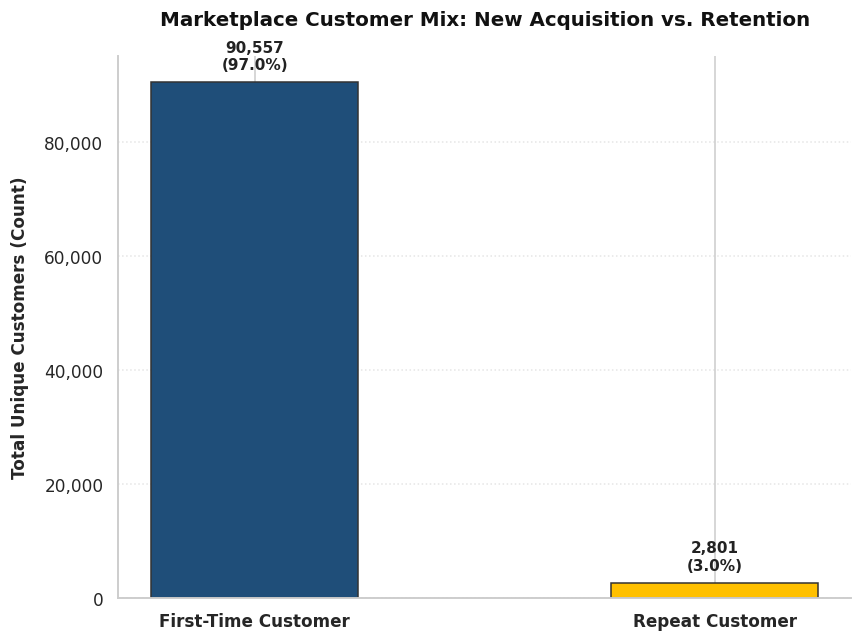

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
from google.cloud import bigquery

# 1. Initialize the BigQuery client
client = bigquery.Client()

# 2. Schema-Corrected SQL Query (o.customer_id joins to c.id)
sql_query = """
WITH customer_order_counts AS (
    -- Link using the exact keys discovered in your schema
    SELECT 
        c.customer_unique_id,
        COUNT(DISTINCT o.id) AS total_orders
    FROM `sctp-team2-project2-elt.olist_gold_mart_prod.fact_orders` AS o
    LEFT JOIN `sctp-team2-project2-elt.olist_gold_mart_prod.dim_customers` AS c
        ON o.customer_id = c.id
    WHERE o.order_status = 'delivered'
      AND c.customer_unique_id IS NOT NULL
    GROUP BY c.customer_unique_id
),
customer_segments AS (
    -- Categorize based on unique customer order history
    SELECT 
        customer_unique_id,
        CASE 
            WHEN total_orders = 1 THEN 'First-Time Customer'
            ELSE 'Repeat Customer'
        END AS customer_type
    FROM customer_order_counts
)
-- Generate final aggregated cohort counts
SELECT 
    customer_type,
    COUNT(customer_unique_id) AS total_customers
FROM customer_segments
GROUP BY customer_type;
"""

print("⏳ Querying BigQuery database (calculating unique customer counts)...")
try:
    # Execute query and stream data straight into a pandas DataFrame
    df = client.query(sql_query).to_dataframe()
    print("✅ Data successfully retrieved from BigQuery!")
except Exception as e:
    print("\n❌ Execution Failed!")
    print(f"Error Details: {e}\n")
    raise

# 3. Calculate processing metrics & sort for consistent layout execution
total_base = df['total_customers'].sum()
df['percentage'] = (df['total_customers'] / total_base) * 100
df = df.sort_values(by='total_customers', ascending=False)

# Print a preview table directly into the notebook logs
print("\n--- Summary Table Results ---")
print(df.to_string(index=False))
print("-----------------------------\n")

# 4. Initialize Matplotlib Figure Layout
fig, ax = plt.subplots(figsize=(8, 6))

# C-Suite Brand Palette (Deep Navy for Acquisition vs. Executive Amber for Retention Leverage)
colors = ['#1f4e79', '#ffc000']

bars = ax.bar(df['customer_type'], df['total_customers'], 
              color=colors[:len(df)], edgecolor='#333333', width=0.45, linewidth=1)

# 5. Chart Polish, Typography & Border Trimming
ax.set_title('Marketplace Customer Mix: New Acquisition vs. Retention', 
             fontsize=13, pad=20, fontweight='bold', color='#111111')
ax.set_ylabel('Total Unique Customers (Count)', fontsize=11, labelpad=10, fontweight='bold')

# Subtle background grid lines prioritizing readability
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.set_axisbelow(True)

# Format y-axis values with standard thousands commas
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax.set_xticklabels(df['customer_type'], fontweight='bold', fontsize=11)

# Strip top and right border spines to maximize presentation whitespace
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# 6. Apply Dynamic Text Labels above Bars (Displays Count + Percentage)
for bar, pct in zip(bars, df['percentage']):
    height = bar.get_height()
    ax.annotate(f"{int(height):,}\n({pct:.1f}%)",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 6),  # 6 points vertical padding above bar
                textcoords="offset points",
                ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='#222222')

plt.tight_layout()

# 7. Render chart directly inside the notebook environment
plt.show()